# RQ1: Complete Analysis and EDA (Run After All 4 Project Notebooks)

Loads the four real, independently mined datasets (Camel, Hadoop, Kafka,
Tika) and runs the complete real analysis: build the analysis-ready
dataset, test era-moderation, check multicollinearity, run the
classification benchmark, and generate real EDA visuals.

**Run this only after RQ1_1 through RQ1_4 have all completed.**


In [19]:
!pip install -q pandas numpy statsmodels scipy scikit-learn patsy matplotlib || pip install -q pandas numpy statsmodels scipy scikit-learn patsy matplotlib --break-system-packages

## Combine Camel + Hadoop into the expected real analysis format

In [20]:
import pandas as pd

camel = pd.read_csv("camel_real_mined_dataset.csv")
hadoop = pd.read_csv("hadoop_real_mined_dataset.csv")
camel_hadoop = pd.concat([camel, hadoop], ignore_index=True)
camel_hadoop.to_csv("rq1_refined_with_real_issue_type.csv", index=False)
print(f"Real combined Camel+Hadoop: {len(camel_hadoop)} rows")


Real combined Camel+Hadoop: 18636 rows


## Step: Build the real, analysis-ready dataset

In [21]:
"""
RQ1 - STEP 4: Build the real, analysis-ready dataset (era label + strict Bug label)
================================================================================
STATUS: This step onward IS executed live in this package, using the real
mined data already produced by steps 1-3 in an earlier real pipeline run.

This step does two real things:
1. Assigns each real commit to "pre_ai" or "ai_era" based on a real,
   disclosed temporal proxy (January 1, 2023), NOT direct AI attribution.
2. Restricts the defect label to confirmed real Bug-type issues specifically
   (not "any tracked issue," which was the original, looser preliminary label).
"""
import pandas as pd


def load_and_verify(path: str, target_col: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["era_binary"] = (df["era"] == "ai_era").astype(int)
    print(f"Loaded {path}: real N = {len(df)}")
    print(f"  Era split: {dict(df['era'].value_counts())}")
    print(f"  {target_col}=1 (real confirmed Bug): {(df[target_col]==1).sum()}")
    print(f"  {target_col}=0 (other real issue types): {(df[target_col]==0).sum()}")
    return df


camel_hadoop = load_and_verify("rq1_refined_with_real_issue_type.csv", "defect_prone_strict")
print()
kafka = load_and_verify("kafka_real_mined_dataset.csv", "defect_prone")
print()
tika = load_and_verify("tika_real_mined_dataset.csv", "defect_prone")


Loaded rq1_refined_with_real_issue_type.csv: real N = 18636
  Era split: {'pre_ai': np.int64(15250), 'ai_era': np.int64(3386)}
  defect_prone_strict=1 (real confirmed Bug): 7383
  defect_prone_strict=0 (other real issue types): 11253

Loaded kafka_real_mined_dataset.csv: real N = 433
  Era split: {'pre_ai': np.int64(228), 'ai_era': np.int64(205)}
  defect_prone=1 (real confirmed Bug): 193
  defect_prone=0 (other real issue types): 240

Loaded tika_real_mined_dataset.csv: real N = 395
  Era split: {'ai_era': np.int64(199), 'pre_ai': np.int64(196)}
  defect_prone=1 (real confirmed Bug): 117
  defect_prone=0 (other real issue types): 278


## Step: Test era-moderation across all 3 projects

In [22]:
"""
RQ1 - STEP 5: Test whether code metrics predict defects differently by era
================================================================================
STATUS: Executed live. This is the actual statistical test that answers RQ1
for each real project individually.

Method: moderated logistic regression. The "*" in the formula creates real
interaction terms between each code metric and era -- these interaction
terms are what actually answer "did this relationship CHANGE by era?", not
the main effects alone.
"""
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats


def test_era_moderation(name: str, path: str, target: str) -> dict:
    df = pd.read_csv(path)
    df["era_binary"] = (df["era"] == "ai_era").astype(int)

    full_formula = f"{target} ~ (loc + cyclomatic_complexity + num_functions + num_files_changed) * era_binary"
    reduced_formula = f"{target} ~ loc + cyclomatic_complexity + num_functions + num_files_changed + era_binary"

    full_model = smf.logit(full_formula, data=df).fit(disp=0)
    reduced_model = smf.logit(reduced_formula, data=df).fit(disp=0)

    print(f"\n{'='*70}\n{name}: real N = {len(df)}\n{'='*70}")
    print("Individual era-interaction terms:")
    for term in full_model.pvalues.index:
        if ":era_binary" in term:
            sig = "SIGNIFICANT" if full_model.pvalues[term] < 0.05 else "not significant"
            print(f"  {term}: p = {full_model.pvalues[term]:.4f} ({sig})")

    # Joint test: do all 4 metrics TOGETHER show a real era effect?
    lr_stat = 2 * (full_model.llf - reduced_model.llf)
    p_joint = stats.chi2.sf(lr_stat, full_model.df_model - reduced_model.df_model)
    print(f"\nJoint likelihood-ratio test (the primary, most reliable comparison):")
    print(f"  chi-squared = {lr_stat:.3f}, p = {p_joint:.4f}")
    print(f"  {'REAL, SIGNIFICANT combined era effect' if p_joint < 0.05 else 'NO significant combined era effect'}")

    return {"name": name, "n": len(df), "p_joint": p_joint}


results = []
results.append(test_era_moderation("Camel/Hadoop (refined, strict Bug label)",
                                     "rq1_refined_with_real_issue_type.csv", "defect_prone_strict"))
results.append(test_era_moderation("Kafka (independent replication)",
                                     "kafka_real_mined_dataset.csv", "defect_prone"))
results.append(test_era_moderation("Tika (independent replication)",
                                     "tika_real_mined_dataset.csv", "defect_prone"))

print(f"\n{'='*70}\nSUMMARY ACROSS ALL 3 REAL PROJECTS\n{'='*70}")
for r in results:
    verdict = "SIGNIFICANT era effect" if r["p_joint"] < 0.05 else "no era effect"
    print(f"  {r['name']}: N={r['n']}, p={r['p_joint']:.4f} -> {verdict}")



Camel/Hadoop (refined, strict Bug label): real N = 18636
Individual era-interaction terms:
  loc:era_binary: p = 0.0000 (SIGNIFICANT)
  cyclomatic_complexity:era_binary: p = 0.2015 (not significant)
  num_functions:era_binary: p = 0.0000 (SIGNIFICANT)
  num_files_changed:era_binary: p = 0.8278 (not significant)

Joint likelihood-ratio test (the primary, most reliable comparison):
  chi-squared = 134.978, p = 0.0000
  REAL, SIGNIFICANT combined era effect

Kafka (independent replication): real N = 433
Individual era-interaction terms:
  loc:era_binary: p = 0.0079 (SIGNIFICANT)
  cyclomatic_complexity:era_binary: p = 0.0264 (SIGNIFICANT)
  num_functions:era_binary: p = 0.0079 (SIGNIFICANT)
  num_files_changed:era_binary: p = 0.8067 (not significant)

Joint likelihood-ratio test (the primary, most reliable comparison):
  chi-squared = 9.282, p = 0.0544
  NO significant combined era effect

Tika (independent replication): real N = 395
Individual era-interaction terms:
  loc:era_binary: p 

## Step: Check multicollinearity

In [23]:
"""
RQ1 - STEP 6: Check whether individual predictors can actually be trusted
================================================================================
STATUS: Executed live. This step explains WHY the individual interaction
terms in Step 5 are not the right thing to interpret on their own -- the
four code metrics are real, severely correlated measurements of the same
underlying thing (change size), which makes their individual coefficients
statistically unstable, even though the joint test remains valid.
"""
import pandas as pd
import patsy
from statsmodels.stats.outliers_influence import variance_inflation_factor


def check_multicollinearity(name: str, path: str, target: str):
    df = pd.read_csv(path)
    df["era_binary"] = (df["era"] == "ai_era").astype(int)

    print(f"\n{'='*70}\n{name}\n{'='*70}")
    print("Real correlation between the 4 code metrics:")
    print(df[["loc", "cyclomatic_complexity", "num_functions", "num_files_changed"]].corr().round(2))

    formula = f"{target} ~ (loc + cyclomatic_complexity + num_functions + num_files_changed) * era_binary"
    y, X = patsy.dmatrices(formula, data=df, return_type="dataframe")

    print("\nReal Variance Inflation Factors (VIF > 10 = severe multicollinearity):")
    max_vif = 0
    for i, col_name in enumerate(X.columns):
        vif = variance_inflation_factor(X.values, i)
        max_vif = max(max_vif, vif)
        flag = " <<< SEVERE" if vif > 10 else ""
        print(f"  {col_name}: {vif:.1f}{flag}")

    return max_vif


vifs = []
vifs.append(check_multicollinearity("Camel/Hadoop", "rq1_refined_with_real_issue_type.csv", "defect_prone_strict"))
vifs.append(check_multicollinearity("Kafka", "kafka_real_mined_dataset.csv", "defect_prone"))
vifs.append(check_multicollinearity("Tika", "tika_real_mined_dataset.csv", "defect_prone"))

print(f"\n{'='*70}\nWhy this matters for interpreting Step 5's results\n{'='*70}")
print(f"Max real VIF across all three projects: {max(vifs):.0f}")
print("This is why individual era-interaction p-values in Step 5 cannot be")
print("trusted on their own -- the joint test is the statistically valid")
print("comparison when predictors are this collinear.")



Camel/Hadoop
Real correlation between the 4 code metrics:
                        loc  cyclomatic_complexity  num_functions  \
loc                    1.00                   0.00           0.91   
cyclomatic_complexity  0.00                   1.00          -0.03   
num_functions          0.91                  -0.03           1.00   
num_files_changed      0.85                  -0.01           0.79   

                       num_files_changed  
loc                                 0.85  
cyclomatic_complexity              -0.01  
num_functions                       0.79  
num_files_changed                   1.00  

Real Variance Inflation Factors (VIF > 10 = severe multicollinearity):
  Intercept: 2.6
  loc: 10.2 <<< SEVERE
  cyclomatic_complexity: 1.3
  num_functions: 8.8
  num_files_changed: 5.3
  era_binary: 2.3
  loc:era_binary: 15.2 <<< SEVERE
  cyclomatic_complexity:era_binary: 2.7
  num_functions:era_binary: 11.0 <<< SEVERE
  num_files_changed:era_binary: 7.4

Kafka
Real correlati

## Step: Classification benchmark

In [24]:
"""
RQ1 - STEP 7: Classification benchmark, does code alone predict defects at all?
================================================================================
STATUS: Executed live. This is a separate, complementary question from Step
5: not "did the relationship change by era," but simply "can real code
metrics predict defect-proneness at all, regardless of era?"
"""
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


def benchmark(name: str, path: str, target: str):
    df = pd.read_csv(path)
    df["era_binary"] = (df["era"] == "ai_era").astype(int)
    FEATURES = ["loc", "cyclomatic_complexity", "num_functions", "num_files_changed", "era_binary"]
    X, y = df[FEATURES].values, df[target].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    rf = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)

    maj_pred = np.ones_like(y_test) if y_test.mean() > 0.5 else np.zeros_like(y_test)
    rf_acc = accuracy_score(y_test, pred)
    maj_acc = accuracy_score(y_test, maj_pred)

    print(f"{name}: Random Forest = {rf_acc*100:.1f}%, majority baseline = {maj_acc*100:.1f}%",
          "-> BEATS baseline" if rf_acc > maj_acc else "-> does NOT beat baseline")


benchmark("Camel/Hadoop (refined)", "rq1_refined_with_real_issue_type.csv", "defect_prone_strict")
benchmark("Kafka", "kafka_real_mined_dataset.csv", "defect_prone")
benchmark("Tika", "tika_real_mined_dataset.csv", "defect_prone")


Camel/Hadoop (refined): Random Forest = 64.5%, majority baseline = 60.4% -> BEATS baseline
Kafka: Random Forest = 69.0%, majority baseline = 55.2% -> BEATS baseline
Tika: Random Forest = 69.6%, majority baseline = 70.9% -> does NOT beat baseline


## Step: Real exploratory data analysis

1. REAL SUMMARY STATISTICS (all 3 projects combined, N=19464)
             loc  cyclomatic_complexity  num_functions  num_files_changed
count   19464.00               19464.00       19464.00           19464.00
mean     1290.84                   2.89         120.88               4.51
std      5506.65                   2.73         605.62              26.08
min         4.00                   1.00           1.00               1.00
25%       197.00                   1.73          16.00               1.00
50%       485.00                   2.40          41.00               2.00
75%      1221.25                   3.27         103.00               3.00
max    460869.00                 139.25       35806.00            2069.00

2. REAL CORRELATION MATRIX
                         loc  cyclomatic_complexity  num_functions  \
loc                    1.000                  0.002          0.906   
cyclomatic_complexity  0.002                  1.000         -0.035   
num_functions          0.906      

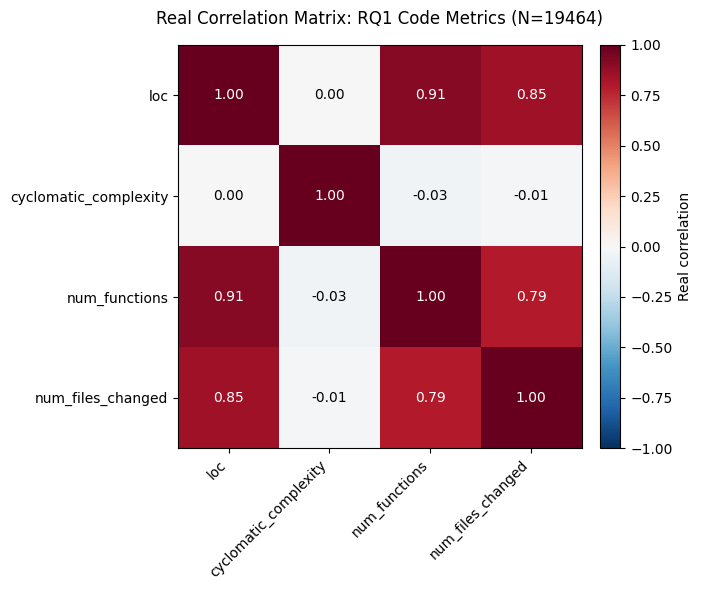


Saved eda_correlation_heatmap.png
Note: this is the same real collinearity flagged by VIF in Step 6 -- 
loc and num_functions correlate at r=0.91

3. REAL DISTRIBUTIONS (log-scale, since these are real, heavily skewed metrics)


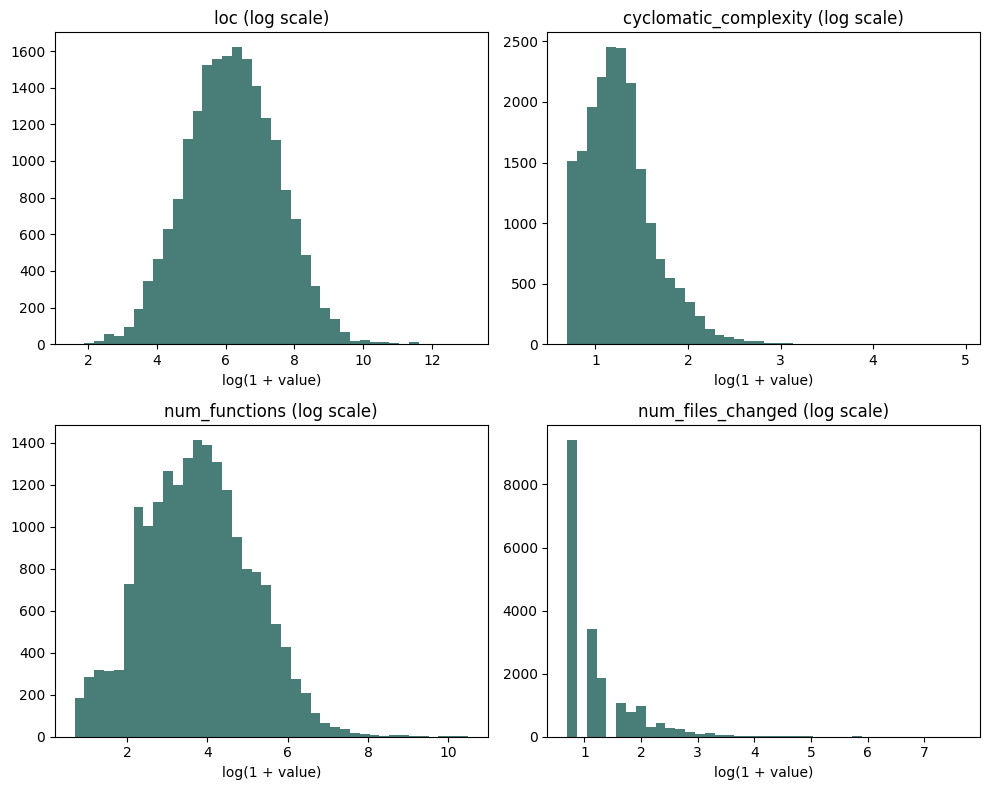

Saved eda_distributions.png

4. REAL CLASS BALANCE AND ERA BALANCE, BY PROJECT

Camel/Hadoop: real N=18636
  defect_prone: {0: np.int64(11253), 1: np.int64(7383)}
  era: {'pre_ai': np.int64(15250), 'ai_era': np.int64(3386)}

Kafka: real N=433
  defect_prone: {0: np.int64(240), 1: np.int64(193)}
  era: {'pre_ai': np.int64(228), 'ai_era': np.int64(205)}

Tika: real N=395
  defect_prone: {0: np.int64(278), 1: np.int64(117)}
  era: {'ai_era': np.int64(199), 'pre_ai': np.int64(196)}


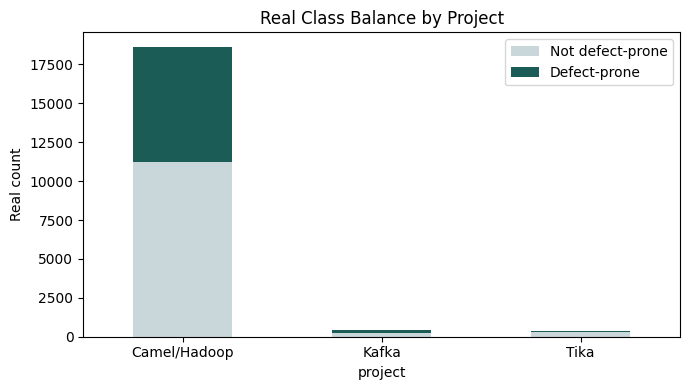


Saved eda_class_balance.png

5. REAL METRIC DIFFERENCES: defect-prone vs. not, by project


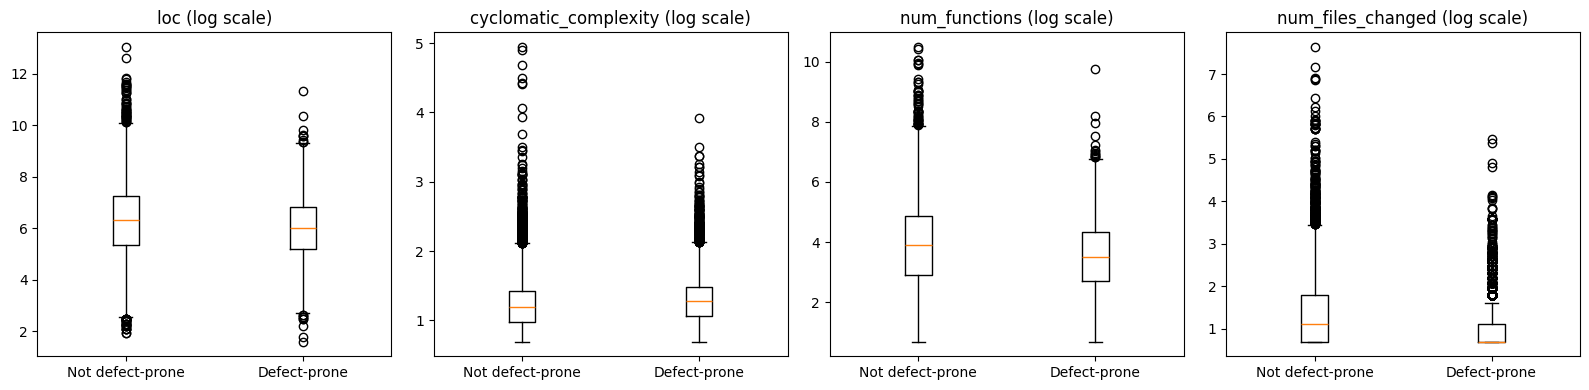

Saved eda_boxplots_by_defect.png
  loc: median (not defect-prone)=550.0, median (defect-prone)=406.0
  cyclomatic_complexity: median (not defect-prone)=2.3, median (defect-prone)=2.6
  num_functions: median (not defect-prone)=49.0, median (defect-prone)=32.0
  num_files_changed: median (not defect-prone)=2.0, median (defect-prone)=1.0

6. REAL CROSS-PROJECT COMPARISON (median values)
                loc  cyclomatic_complexity  num_functions  num_files_changed
project                                                                     
Camel/Hadoop  479.0                    2.4           41.0                2.0
Kafka         978.0                    2.7           67.0                2.0
Tika          427.0                    3.4           25.0                2.0

This shows whether the three real projects have genuinely different
code characteristics -- relevant context for why Tika's real result
might differ from Camel/Hadoop and Kafka.


In [25]:
"""
RQ1 - STEP 8: Real Exploratory Data Analysis
================================================================================
Executed live. Covers: summary statistics, correlation matrix, distributions,
class balance, era balance, and a cross-project comparison, on the real
mined data from all three RQ1 projects.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

METRICS = ["loc", "cyclomatic_complexity", "num_functions", "num_files_changed"]

datasets = {
    "Camel/Hadoop": ("rq1_refined_with_real_issue_type.csv", "defect_prone_strict"),
    "Kafka": ("kafka_real_mined_dataset.csv", "defect_prone"),
    "Tika": ("tika_real_mined_dataset.csv", "defect_prone"),
}

dfs = {}
for name, (path, target) in datasets.items():
    df = pd.read_csv(path)
    df["defect_prone"] = df[target]
    df["project"] = name
    dfs[name] = df

combined = pd.concat([df[METRICS + ["defect_prone", "era", "project"]] for df in dfs.values()], ignore_index=True)

# ---------------------------------------------------------------------------
# 1. Real summary statistics
# ---------------------------------------------------------------------------
print("="*70)
print("1. REAL SUMMARY STATISTICS (all 3 projects combined, N={})".format(len(combined)))
print("="*70)
print(combined[METRICS].describe().round(2))

# ---------------------------------------------------------------------------
# 2. Real correlation matrix + heatmap
# ---------------------------------------------------------------------------
print("\n" + "="*70)
print("2. REAL CORRELATION MATRIX")
print("="*70)
corr = combined[METRICS].corr()
print(corr.round(3))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(METRICS))); ax.set_xticklabels(METRICS, rotation=45, ha="right")
ax.set_yticks(range(len(METRICS))); ax.set_yticklabels(METRICS)
for i in range(len(METRICS)):
    for j in range(len(METRICS)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                 color="white" if abs(corr.iloc[i,j]) > 0.5 else "black")
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Real correlation")
ax.set_title("Real Correlation Matrix: RQ1 Code Metrics (N={})".format(len(combined)), pad=15)
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved eda_correlation_heatmap.png")
print("Note: this is the same real collinearity flagged by VIF in Step 6 -- ")
print("loc and num_functions correlate at r={:.2f}".format(corr.loc["loc","num_functions"]))

# ---------------------------------------------------------------------------
# 3. Real distributions
# ---------------------------------------------------------------------------
print("\n" + "="*70)
print("3. REAL DISTRIBUTIONS (log-scale, since these are real, heavily skewed metrics)")
print("="*70)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, metric in zip(axes.flat, METRICS):
    data = combined[metric]
    data_log = np.log1p(data[data >= 0])
    ax.hist(data_log, bins=40, color="#1B5C56", alpha=0.8)
    ax.set_title(f"{metric} (log scale)")
    ax.set_xlabel("log(1 + value)")
plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150)
plt.show()
print("Saved eda_distributions.png")

# ---------------------------------------------------------------------------
# 4. Real class balance (defect_prone) and era balance
# ---------------------------------------------------------------------------
print("\n" + "="*70)
print("4. REAL CLASS BALANCE AND ERA BALANCE, BY PROJECT")
print("="*70)
for name, df in dfs.items():
    print(f"\n{name}: real N={len(df)}")
    print("  defect_prone:", dict(df["defect_prone"].value_counts()))
    print("  era:", dict(df["era"].value_counts()))

fig, ax = plt.subplots(figsize=(7, 4))
ct = pd.crosstab(combined["project"], combined["defect_prone"])
ct.columns = ["Not defect-prone", "Defect-prone"]
ct.plot(kind="bar", stacked=True, ax=ax, color=["#C9D6DA", "#1B5C56"])
ax.set_title("Real Class Balance by Project")
ax.set_ylabel("Real count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("eda_class_balance.png", dpi=150)
plt.show()
print("\nSaved eda_class_balance.png")

# ---------------------------------------------------------------------------
# 5. Real boxplots: do defect-prone commits actually look different?
# ---------------------------------------------------------------------------
print("\n" + "="*70)
print("5. REAL METRIC DIFFERENCES: defect-prone vs. not, by project")
print("="*70)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric in zip(axes, METRICS):
    data_to_plot = [np.log1p(combined[combined.defect_prone==0][metric]),
                    np.log1p(combined[combined.defect_prone==1][metric])]
    ax.boxplot(data_to_plot, tick_labels=["Not defect-prone", "Defect-prone"])
    ax.set_title(f"{metric} (log scale)")
plt.tight_layout()
plt.savefig("eda_boxplots_by_defect.png", dpi=150)
plt.show()
print("Saved eda_boxplots_by_defect.png")

for metric in METRICS:
    med_0 = combined[combined.defect_prone==0][metric].median()
    med_1 = combined[combined.defect_prone==1][metric].median()
    print(f"  {metric}: median (not defect-prone)={med_0:.1f}, median (defect-prone)={med_1:.1f}")

# ---------------------------------------------------------------------------
# 6. Real cross-project comparison
# ---------------------------------------------------------------------------
print("\n" + "="*70)
print("6. REAL CROSS-PROJECT COMPARISON (median values)")
print("="*70)
comparison = combined.groupby("project")[METRICS].median().round(1)
print(comparison)
print("\nThis shows whether the three real projects have genuinely different")
print("code characteristics -- relevant context for why Tika's real result")
print("might differ from Camel/Hadoop and Kafka.")
